In [15]:
!pip install openpyxl

import pandas as pd
import sqlite3

In [16]:
from google.colab import files
uploaded = files.upload()

Saving BlinkIT Grocery Data.xlsx to BlinkIT Grocery Data.xlsx


In [17]:
df = pd.read_excel("BlinkIT Grocery Data.xlsx")

# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.head()

,Item_Fat_Content,Item_Identifier,Item_Type,Outlet_Establishment_Year,Outlet_Identifier,Outlet_Location_Type,Outlet_Size,Outlet_Type,Item_Visibility,Item_Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [18]:
conn = sqlite3.connect(":memory:")
df.to_sql("blinkit", conn, index=False, if_exists="replace")

8523

In [19]:
pd.read_sql("""
SELECT
    ROUND(SUM(Sales),2) AS Total_Sales
FROM blinkit
""", conn)

,Total_Sales
0,1201681.49


In [20]:
pd.read_sql("""
SELECT COUNT(DISTINCT Item_Identifier) AS Unique_Items
FROM blinkit
""", conn)

,Unique_Items
0,1559


In [21]:
pd.read_sql("""
SELECT ROUND(AVG(Sales),2) AS Avg_Sales
FROM blinkit
""", conn)

,Avg_Sales
0,140.99


In [22]:
pd.read_sql("""
SELECT
    Outlet_Type,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM blinkit
GROUP BY Outlet_Type
ORDER BY Total_Sales DESC
""", conn)

,Outlet_Type,Total_Sales
0,Supermarket Type1,787549.89
1,Grocery Store,151939.15
2,Supermarket Type2,131477.78
3,Supermarket Type3,130714.67


In [23]:
pd.read_sql("""
SELECT
    Outlet_Location_Type,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM blinkit
GROUP BY Outlet_Location_Type
ORDER BY Total_Sales DESC
""", conn)

,Outlet_Location_Type,Total_Sales
0,Tier 3,472133.03
1,Tier 2,393150.65
2,Tier 1,336397.81


In [24]:
pd.read_sql("""
SELECT
    Outlet_Size,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM blinkit
GROUP BY Outlet_Size
ORDER BY Total_Sales DESC
""", conn)

,Outlet_Size,Total_Sales
0,Medium,507895.74
1,Small,444794.17
2,High,248991.59


In [25]:
pd.read_sql("""
SELECT
    Item_Identifier,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM blinkit
GROUP BY Item_Identifier
ORDER BY Total_Sales DESC
LIMIT 10
""", conn)

,Item_Identifier,Total_Sales
0,FDU12,2371.01
1,FDT07,2306.90
2,NCQ06,2294.71
3,FDL58,2111.65
4,NCB31,2104.73
5,FDX31,2104.46
6,FDF05,2103.13
7,FDR59,2096.58
8,FDP28,2087.85
9,FDA04,2072.07


In [26]:
pd.read_sql("""
SELECT
    Item_Type,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM blinkit
GROUP BY Item_Type
ORDER BY Total_Sales DESC
""", conn)

,Item_Type,Total_Sales
0,Fruits and Vegetables,178124.08
1,Snack Foods,175433.92
2,Household,135976.53
3,Frozen Foods,118558.88
4,Dairy,101276.46
5,Canned,90706.73
6,Baking Goods,81894.74
7,Health and Hygiene,68025.84
8,Meat,59449.86
9,Soft Drinks,58514.17


In [27]:
pd.read_sql("""
SELECT
    Item_Fat_Content,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM blinkit
GROUP BY Item_Fat_Content
ORDER BY Total_Sales DESC
""", conn)

,Item_Fat_Content,Total_Sales
0,Low Fat,717390.85
1,Regular,409413.12
2,LF,43857.11
3,reg,15948.68
4,low fat,15071.73


In [28]:
pd.read_sql("""
SELECT
    Outlet_Identifier,
    ROUND(SUM(Sales),2) AS Total_Sales,
    RANK() OVER (ORDER BY SUM(Sales) DESC) AS Sales_Rank
FROM blinkit
GROUP BY Outlet_Identifier
""", conn)

,Outlet_Identifier,Total_Sales,Sales_Rank
0,OUT035,133103.91,1
1,OUT046,132113.37,2
2,OUT013,131809.02,3
3,OUT018,131477.78,4
4,OUT045,130942.78,5
5,OUT027,130714.67,6
6,OUT049,130476.86,7
7,OUT017,129103.96,8
8,OUT010,78131.57,9
9,OUT019,73807.58,10


In [29]:
pd.read_sql("""
WITH item_sales AS (
    SELECT
        Outlet_Identifier,
        Item_Identifier,
        SUM(Sales) AS Total_Sales
    FROM blinkit
    GROUP BY Outlet_Identifier, Item_Identifier
),
ranked_items AS (
    SELECT *,
        RANK() OVER (
            PARTITION BY Outlet_Identifier
            ORDER BY Total_Sales DESC
        ) AS rnk
    FROM item_sales
)
SELECT *
FROM ranked_items
WHERE rnk = 1
""", conn)

,Outlet_Identifier,Item_Identifier,Total_Sales,rnk
0,OUT010,FDK51,266.6884,1
1,OUT013,NCS29,266.6884,1
2,OUT017,FDS13,266.8884,1
3,OUT018,FDR25,265.1884,1
4,OUT019,FDS13,266.5884,1
5,OUT027,FDK51,265.2884,1
6,OUT035,NCS29,266.5884,1
7,OUT045,FDR25,265.7884,1
8,OUT046,FDR25,266.8884,1
9,OUT049,NCS29,266.2884,1


In [30]:
pd.read_sql("""
WITH total AS (
    SELECT SUM(Sales) AS grand_total FROM blinkit
)
SELECT
    b.Outlet_Type,
    ROUND(SUM(b.Sales),2) AS Total_Sales,
    ROUND(SUM(b.Sales) * 100.0 / t.grand_total,2) AS Contribution_Percentage
FROM blinkit b, total t
GROUP BY b.Outlet_Type
ORDER BY Total_Sales DESC
""", conn)

,Outlet_Type,Total_Sales,Contribution_Percentage
0,Supermarket Type1,787549.89,65.54
1,Grocery Store,151939.15,12.64
2,Supermarket Type2,131477.78,10.94
3,Supermarket Type3,130714.67,10.88


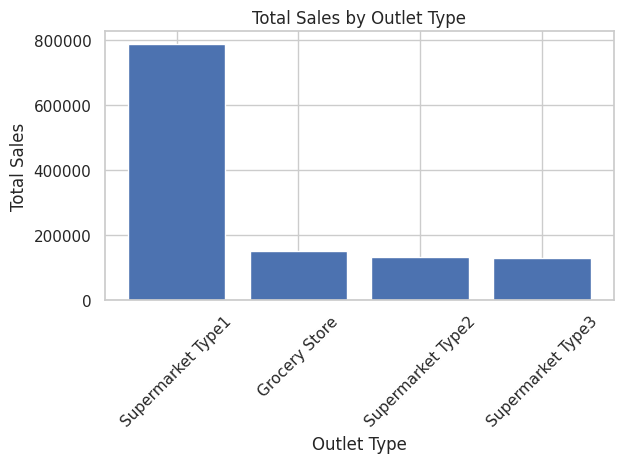

In [33]:
sales_outlet = pd.read_sql("""
SELECT Outlet_Type, SUM(Sales) AS Total_Sales
FROM blinkit
GROUP BY Outlet_Type
ORDER BY Total_Sales DESC
""", conn)

plt.figure()
plt.bar(sales_outlet["Outlet_Type"], sales_outlet["Total_Sales"])
plt.xticks(rotation=45)
plt.title("Total Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

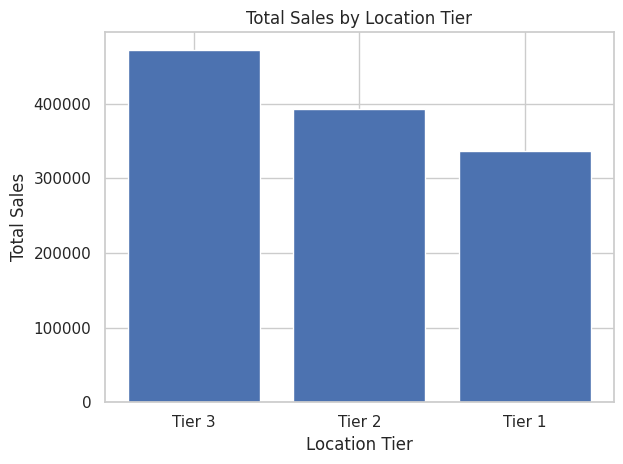

In [34]:
sales_location = pd.read_sql("""
SELECT Outlet_Location_Type, SUM(Sales) AS Total_Sales
FROM blinkit
GROUP BY Outlet_Location_Type
ORDER BY Total_Sales DESC
""", conn)

plt.figure()
plt.bar(sales_location["Outlet_Location_Type"], sales_location["Total_Sales"])
plt.title("Total Sales by Location Tier")
plt.xlabel("Location Tier")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

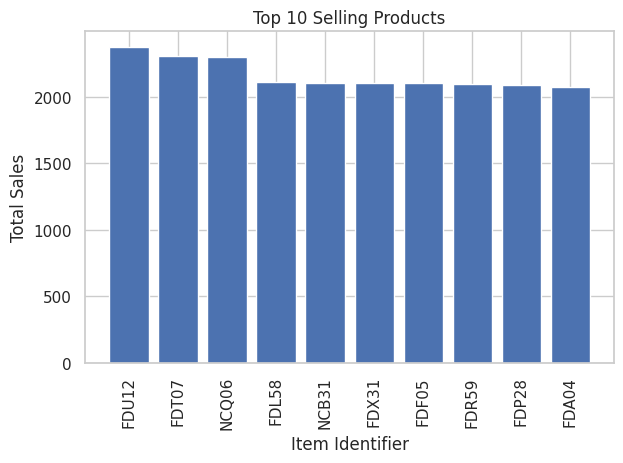

In [35]:
top_items = pd.read_sql("""
SELECT Item_Identifier, SUM(Sales) AS Total_Sales
FROM blinkit
GROUP BY Item_Identifier
ORDER BY Total_Sales DESC
LIMIT 10
""", conn)

plt.figure()
plt.bar(top_items["Item_Identifier"], top_items["Total_Sales"])
plt.xticks(rotation=90)
plt.title("Top 10 Selling Products")
plt.xlabel("Item Identifier")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

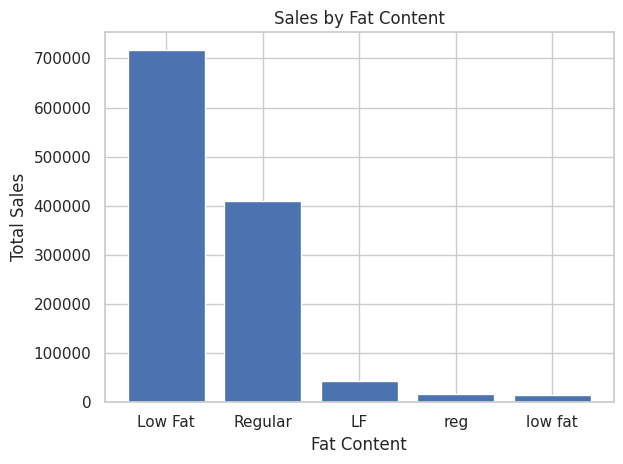

In [36]:
fat_sales = pd.read_sql("""
SELECT Item_Fat_Content, SUM(Sales) AS Total_Sales
FROM blinkit
GROUP BY Item_Fat_Content
ORDER BY Total_Sales DESC
""", conn)

plt.figure()
plt.bar(fat_sales["Item_Fat_Content"], fat_sales["Total_Sales"])
plt.title("Sales by Fat Content")
plt.xlabel("Fat Content")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

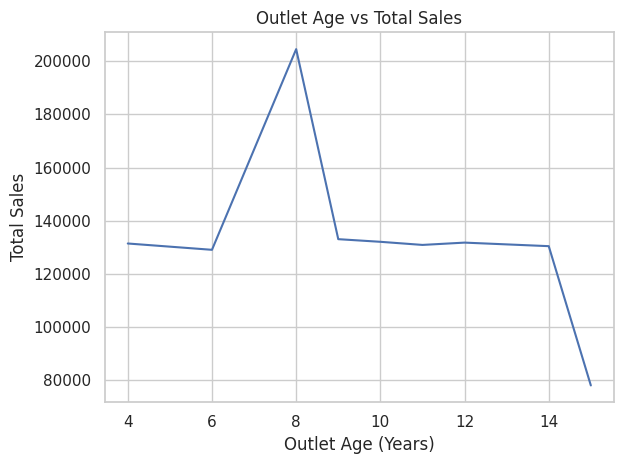

In [37]:
age_sales = pd.read_sql("""
SELECT
    (strftime('%Y','now') - Outlet_Establishment_Year) AS Outlet_Age,
    SUM(Sales) AS Total_Sales
FROM blinkit
GROUP BY Outlet_Age
ORDER BY Outlet_Age
""", conn)

plt.figure()
plt.plot(age_sales["Outlet_Age"], age_sales["Total_Sales"])
plt.title("Outlet Age vs Total Sales")
plt.xlabel("Outlet Age (Years)")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

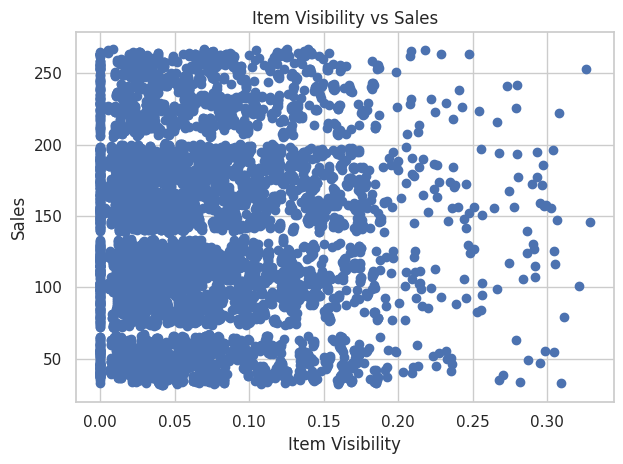

In [38]:
plt.figure()
plt.scatter(df["Item_Visibility"], df["Sales"])
plt.title("Item Visibility vs Sales")
plt.xlabel("Item Visibility")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()